## Importing libraries and datasets


In [ ]:
#Installing important and necessary libraries
!pip install split-folders
!pip install img2vec_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [ ]:
# Importing Libraries
import splitfolders
import os
import zipfile
# Connecting to Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Extracting all the images from the zipfile
zip_file = '/content/drive/My Drive/data/Bone_Fracture_Binary_Classification.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [ ]:
input_folder = "/content/dataset/Bone_Fracture_Binary_Classification"
#Splitting the dataset into Train, test and val with 70% is train, 20% is Validation and 10% is Test
splitfolders.ratio(input_folder, output="/content/output", seed=42, ratio=(.7, .2, .1), group_prefix=None)

Copying files: 9548 files [00:06, 1436.37 files/s]


In [ ]:
# Assigning the pathway to each train, test and validation data
Test = '/content/output/test'
Val = '/content/output/val'
Train = '/content/output/train'

# Setting batch size, image width and height
img_width = 128
img_height = 128
batch_size = 16

In [ ]:
# Import ImageDataGenerator (Allows for data augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Making sure that the picture is normalised // (Data Augmentation)
train_datagen = ImageDataGenerator(rescale = 1./255, # Normalises the pixel values of the image
                                   shear_range=0.2, # Shearing transformation on the image
                                   zoom_range=0.2, # Zooms ont he Image
                                   rotation_range=45, # Rotates the images based on input
                                   horizontal_flip=True, #Flipping image
                                   vertical_flip=True)

# Only Applying data augmentation to train so that we can test the accuracy of CNN honestly
test_datagen = ImageDataGenerator(rescale = 1./255,)

In [ ]:
# Manages any corrupted images
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Flow images in batches from train directory
train_generator = train_datagen.flow_from_directory( #Flow from directory assigns labels based on the folder the image is in
    directory = Train, #Which directory to flow the images from
    target_size=(img_width, img_height), # All images flowing will be resized to the target size
    batch_size=batch_size,
    class_mode='binary' #Class mode, in our case we have 2 classes so we've decided to set as "binary"
)

# Flow images in batches from val directory
val_generator = train_datagen.flow_from_directory(
    directory= Val,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode= 'binary'
)

# Flow images in batches from test directory
test_generator = test_datagen.flow_from_directory(
    directory = Test,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

Found 6683 images belonging to 2 classes.
Found 1909 images belonging to 2 classes.
Found 956 images belonging to 2 classes.


## Constructing the Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
model = models.Sequential()
#First Layer of Convolution Layer
# Set Number of filters and kernel size for each layer.
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)))
model.add(layers.MaxPooling2D((2, 2)))
#Second Layer of COnvolution Layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
# Flatten the last layer to connect with fully connected layer
model.add(layers.Flatten())
#Fully Connected Layer
model.add(layers.Dense(64, activation='relu'))
#Output Layer
model.add(layers.Dense(1 ,activation='sigmoid') )

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │       3,686,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, AUC
# Adam is the commonly used optimiser
# Decide on model architecture
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy', Precision(), Recall(), AUC()])

# Training the model
history = model.fit(train_generator, epochs= 10,
                    validation_data= val_generator)


Epoch 1/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 208s 488ms/step - accuracy: 0.6171 - auc_2: 0.6704 - loss: 0.6557 - precision_2: 0.6136 - recall_2: 0.4969 - val_accuracy: 0.7156 - val_auc_2: 0.7948 - val_loss: 0.5729 - val_precision_2: 0.6577 - val_recall_2: 0.8653
Epoch 2/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 204s 487ms/step - accuracy: 0.7253 - auc_2: 0.8008 - loss: 0.5401 - precision_2: 0.7086 - recall_2: 0.7169 - val_accuracy: 0.7983 - val_auc_2: 0.8824 - val_loss: 0.4503 - val_precision_2: 0.8339 - val_recall_2: 0.7306
Epoch 3/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 207s 494ms/step - accuracy: 0.7970 - auc_2: 0.8722 - loss: 0.4458 - precision_2: 0.7844 - recall_2: 0.8017 - val_accuracy: 0.8376 - val_auc_2: 0.9188 - val_loss: 0.3630 - val_precision_2: 0.8012 - val_recall_2: 0.8858
Epoch 4/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 212s 507ms/step - accuracy: 0.8494 - auc_2: 0.9222 - loss: 0.3541 - precision_2: 0.8324 - recall_2: 0.8693 - val_accuracy: 0.8785 - val_auc_2: 0.9491 - val_loss: 0.2910 - val_precision_2

In [ ]:
# Performance Metrics
loss, accuracy , precision , recall, AUC = model.evaluate(test_generator) #Testing the training model by using the test dataset
# the output will be the performance metrics
print(f"Test Loss: {loss:.4f}") #Test Loss
print(f"Test Accuracy: {accuracy:.4f}") #Test Accuracy
print(f"Precision: {precision:.4f}") #Precision
print(f"Recall: {recall:.4f}") #Recall
print(f"AUC: {AUC:.4f}") #Area Under Curve

60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9728 - auc_2: 0.9928 - loss: 0.0896 - precision_2: 0.9657 - recall_2: 0.9776
Test Loss: 0.1020
Test Accuracy: 0.9738
Precision: 0.9641
Recall: 0.9828
AUC: 0.9915


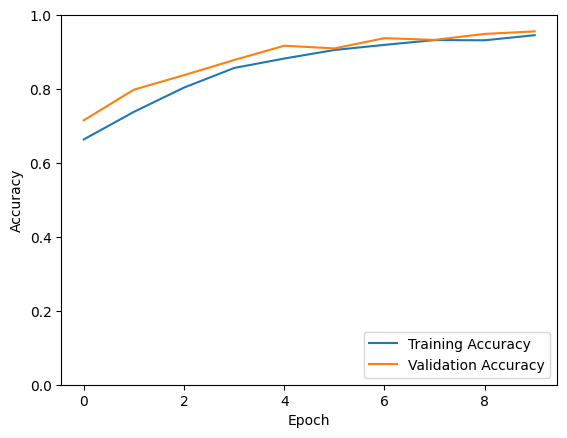

In [ ]:
# Visualising the trend of Training Accuracy and Validation Accuracy based on epoch
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy') #Plotting Training Accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') #Plotting Validation Accuracy
plt.xlabel('Epoch') #Name for X Label // Axis
plt.ylabel('Accuracy') #Name of Y Label // Axis
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

## Model 2
Using different number of layers of Convolutional Layers


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
model2 = models.Sequential()
#First Layer of Convolution Layer
# Set Number of filters and kernel size for each layer.
model2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)))
model2.add(layers.MaxPooling2D((2, 2)))
#Second Layer of Convolution Layer
model2.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))
#Third Layer of Convolution Layer
model2.add(layers.Conv2D(128, (3, 3), activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))
# Flatten the last layer to connect with fully connected layer
model2.add(layers.Flatten())
#Fully Connected Layer
model2.add(layers.Dense(64, activation='relu'))
#Output Layer
model2.add(layers.Dense(1 ,activation='sigmoid') )

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, AUC
# Adam is the commonly used optimiser
# Decide on model architecture
model2.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy', Precision(), Recall(), AUC()])

# Training the Model
history2 = model2.fit(train_generator, epochs= 10,
                    validation_data= val_generator)

# Performance Metrics
loss2, accuracy2 , precision2 , recall2, AUC2 = model2.evaluate(test_generator) #Testing the training model by using the test dataset
print(f"Test Loss: {loss2:.4f}") # Performance of Test Loss
print(f"Test Accuracy: {accuracy2:.4f}") #Performance on test accuracy
print(f"Precision: {precision2:.4f}") # Precision
print(f"Recall: {recall2:.4f}") #Recall
print(f"AUC: {AUC2:.4f}") #Area Under Curve

Epoch 1/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 255s 603ms/step - accuracy: 0.5414 - auc_3: 0.5720 - loss: 0.6829 - precision_3: 0.5253 - recall_3: 0.4239 - val_accuracy: 0.6255 - val_auc_3: 0.7168 - val_loss: 0.6296 - val_precision_3: 0.6582 - val_recall_3: 0.4774
Epoch 2/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 259s 597ms/step - accuracy: 0.6733 - auc_3: 0.7288 - loss: 0.6016 - precision_3: 0.6493 - recall_3: 0.7018 - val_accuracy: 0.7423 - val_auc_3: 0.8181 - val_loss: 0.5173 - val_precision_3: 0.6982 - val_recall_3: 0.8276
Epoch 3/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 262s 597ms/step - accuracy: 0.7271 - auc_3: 0.8086 - loss: 0.5155 - precision_3: 0.6855 - recall_3: 0.7954 - val_accuracy: 0.7858 - val_auc_3: 0.8608 - val_loss: 0.4525 - val_precision_3: 0.7488 - val_recall_3: 0.8416
Epoch 4/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 250s 595ms/step - accuracy: 0.8014 - auc_3: 0.8804 - loss: 0.4237 - precision_3: 0.7693 - recall_3: 0.8560 - val_accuracy: 0.8114 - val_auc_3: 0.8920 - val_loss: 0.4130 - val_precision_3

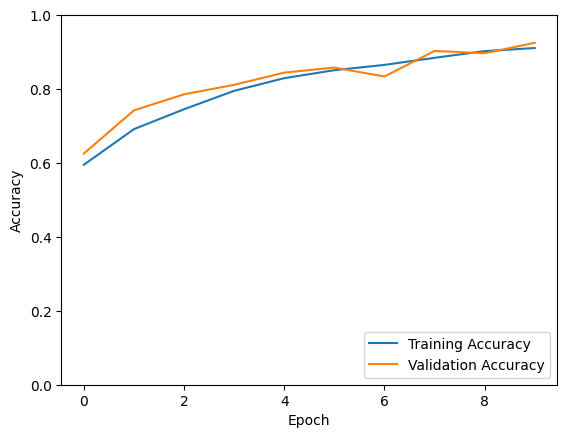

In [ ]:
# Visualising the trend of Training Accuracy and Validation Accuracy based on epoch
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'], label='Training Accuracy') #Plotting Training Accuracy
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy') #Plotting Validation Accuracy
plt.xlabel('Epoch') #Name for X Label // Axis
plt.ylabel('Accuracy') #Name for Y Label // Axis
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

Confusion Matrix for the higher performance model

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
y_pred = model.predict(test_generator)  # Get predictions
y_pred_classes = (y_pred > 0.5).astype(int)  # Convert predictions to class labels (0 or 1)

y_true = test_generator.classes  # Get actual labels
cm = confusion_matrix(y_true, y_pred_classes) #Generate Confusion matrix

60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step


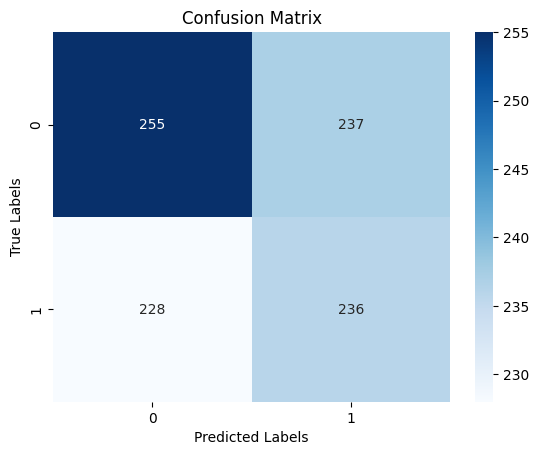

In [ ]:
# Plot the confusion matrix using Seaborn heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()